In [23]:
#自動分析プログラムの実装

# -------------------------------------------------------------------------------------
#                       読み込み部
# -------------------------------------------------------------------------------------

import pandas as pd
import csv
import numpy as np
import os

#パラメータ(変更)
d = 3.0 * pow(10,-4)  #直径
L = 4.0 * pow(10,-2)  #長さ
P = 101.63  #大気圧
Setting_Temp = 80  #液温
overlap_n = 8  #データロガーのデータをオーバーラップ処理する時、何個ずつにするかを指定(録音時間が1minだと4, 2minだと10がベター)
shunt_s = 1.0 * pow(10,-4) #標準偏差のしきい値(シャント電圧)
Pt_s = 1.0 * pow(10,-3) #標準偏差のしきい値(白金電圧)
# list_maxHz = [2000, 3000, 10000, 20000] #パワースペクトルグラフの横軸最大値
list_maxHz = [3000] #パワースペクトルグラフの横軸最大値


#自然対流領域の判定に用いるデータの最低数
dataplot_min = 9

#入力フォルダの指定
input_folder = r"C:\Users\Casper4\Python\ueki\shibasaki\研究\Pool_boiling\Subcooling_20_degrees\0.3\2024.11.12_1\録音データ"
dir_path=os.path.dirname(input_folder)

#出力フォルダの指定
save_path=os.path.join(dir_path, '実験結果' + os.path.basename(dir_path))
save_area_path = os.path.join(save_path, '非沸騰領域のグラフ')
save_time_path = os.path.join(save_path, 'time')

save_all_path = os.path.dirname(dir_path)
save_area_all_path = os.path.join(save_all_path, '非沸騰領域のグラフ')

#csvファイルの選択
read_csv_file = os.path.join(dir_path, os.path.basename(dir_path) + '.csv')

# -------------------------------------------------------------------------------------

# -------------------------------------------------------------------------------------

#フォルダの作成
#os.makedirs(save_path, exist_ok=True)
os.makedirs(save_area_path, exist_ok=True)
os.makedirs(save_time_path, exist_ok=True)
os.makedirs(save_area_all_path, exist_ok=True)

#csvファイルの読み込み
df = pd.read_csv(read_csv_file, skiprows = 12, usecols =[2, 4, 6] , encoding='cp932')  #不要な部分をスキップして取り出す
pd.set_option('display.max_rows', 30)  #最大表示数の指定　
df = df.dropna()  #NaNがあれば削除

#csvファイルの3列目(水温),5列目(シャント電圧),7列目(白金電圧)
#column名の一括変更
df = df.rename(columns={'101 <水温> (C)': 'water', '102 <シャント抵抗> (VDC)': 'shunt', '103 <電極電圧> (VDC)': 'Pt'})

#indexの数値を変更(スキャン番号と一致)
#df.index = df.index + (数値)
df.index = df.index + 1

#データ整理の前準備
processing_df0 = df.copy() # データを複製して、編集用のデータフレームにする
pd.options.display.float_format = '{:.8f}'.format  #数値の小数点以下の桁数を指定

##測定条件のデータ整理
#水温を許容誤差内に(目標温度±1℃)
df_P0 = processing_df0.query('@Setting_Temp - 1 <= water <= @Setting_Temp + 1')

#電圧印加後(shuntの値による抽出)
df_P0 = df_P0.query('shunt > 0.001')

#0.0VでのDataFrameを追加する
start_index = max(0, df_P0.index[0] - (overlap_n + 4))
end_index = min(len(df), df_P0.index[0] -1)
result_indices = list(range(start_index, end_index))
result_df = df.iloc[result_indices]

#DataFrameを連結して0.0V～のデータに変更
df_P0 = pd.concat([result_df, df_P0])

#水温の平均
T_bulk = df_P0['water'].mean()                  #T_bulkに相当する水温の算出
print("T_bulk:", T_bulk)

processing_df1 = df_P0.copy() # データを複製して、編集用のデータフレームにする


T_bulk: 79.97852061855669


In [24]:
# -------------------------------------------------------------------------------------
#                       条件抽出部
# -------------------------------------------------------------------------------------

import os
import math

#標準偏差の関数
def stdev(input_list):
    
    array = np.array(input_list)
    
    average = array.mean()   #平均
    
    deviation_square_sum = 0
    
    #columnの各要素で偏差平方の計算
    for i in range(len(array)):
        
        deviation = array[i] - average       #偏差
        deviation_Square = deviation ** 2   #偏差平方(2乗)
        deviation_square_sum += deviation_Square 
    
    #分散
    variance = deviation_square_sum / len(array)
    
    #標準偏差
    standard_deviation = math.sqrt(variance)
    
    return average, standard_deviation  

#作成した二次元配列では同じ数値の並びを持つ配列が存在する
#共通の部分列を探し、重複部分を削除する

def find_common_subsequence(matching_lists1, matching_lists2):
    
    #2つの配列から共通の部分列を見つける
    m, n = len(matching_lists1), len(matching_lists2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if matching_lists1[i - 1] == matching_lists2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    #共通の部分列を取得する
    i, j = m, n
    common_subsequence = []
    
    while i > 0 and j > 0:
        if matching_lists1[i - 1] == matching_lists2[j - 1]:
            common_subsequence.append(matching_lists1[i - 1])
            i -= 1
            j -= 1
        elif dp[i - 1][j] > dp[i][j - 1]:
            i -= 1
        else:
            j -= 1

    return common_subsequence[::-1]

def merge_arrays_with_common_subsequence(matching_lists):
    
    i = 0
    while i < len(matching_lists) - 1:
        common_subsequence = find_common_subsequence(matching_lists[i], matching_lists[i + 1])
        if common_subsequence:
            #配列を結合し、共通の部分列を削除
            matching_lists[i] += matching_lists[i + 1][len(common_subsequence):]
            matching_lists.pop(i + 1)
        else:
            i += 1
    


In [25]:
# -------------------------------------------------------------------------------------
#                       シャント電圧計算部
# -------------------------------------------------------------------------------------

##測定開始
##シャント電圧
df_P1 = processing_df1
#DataFrameをSeriesに変更
df_PS = df_P1['shunt']  #df_P1['']→listに変換できる、df_P1[['']]→DataFrameとして表示できる

#Seriesをlistに変換
list_shunt = df_PS.to_list()

#listからデータをn個ずつ抽出して標準偏差を計算してkだけスキップする(オーバーラップ処理)→range(start, finish, k)  k=5,6は不適
n = overlap_n
#arrayを作成する時、エラーが生じないようにrange関数に格納するfinishをずらす処理
L_shunt = len(list_shunt)
L_shunt = L_shunt - (n - 1)

list_result = []   #空の配列を用意
for i in range(0, L_shunt, 1):  #i:indexの個数に相当    #k=1として設定。k=3,4の場合実験中の不備による穴抜けが発生する可能性がある

    #n個間隔で抽出したデータに対し、n-1番目まで数値をそれぞれ求めて配列に格納する    
  
    row = []   #空の配列を用意
    for j in range(n):
        element = list_shunt[i+j]
        row.append(element)   #rowリストにelementを順次追加  row.append(i + j)←二次元配列をリストに格納したい
    list_result.append(row) #行を二次元配列に追加   #配列は条件全ての要素含む
#print(list_result)

#標準偏差を用いて配列を分類、条件に合致するリストのみ抽出する
#空の行列を用意
matching_lists1 = []   
matching_average1 = []  
matching_stdev1 = []  
pre_matching_average1 = [] 
pre_matching_stdev1 = []  

for sublist in list_result:
    average1, std_deviation_value1 = stdev(sublist)
    
    # -------------------------------------------------------------------------------------
    pre_matching_average1.append(average1)  #マッチする前の平均値の検出
    pre_matching_stdev1.append(std_deviation_value1)  #マッチする前の標準偏差の検出
    debug_data_shunt=[pre_matching_average1, pre_matching_stdev1]
    #df_debug_shunt = pd.DataFrame({'pre_shunt_ave':pre_matching_average1, 'pre_shunt_std':pre_matching_stdev1})
    df_debug_shunt = pd.DataFrame(debug_data_shunt).transpose() #transpose()を使って行と列を入れ替え
    # -------------------------------------------------------------------------------------
    
    if std_deviation_value1 < shunt_s:  #標準偏差の値よりも小さい場合を抽出(参考：1.0e-04)
        matching_lists1.append(sublist)        #マッチしたリストの検出
        matching_average1.append(average1)     #マッチした平均値の検出
        matching_stdev1.append(std_deviation_value1) #マッチした標準偏差の検出
#print(matching_lists1)

#共通の部分列を探して配列を結合し、重複を削除する
merge_arrays_with_common_subsequence(matching_lists1)

#最終的な二次元配列から求めた最終的な平均値
shunt_average = []
for row in matching_lists1:
    average_shunt_fin = sum(row) / len(row)   #平均
    shunt_average.append(average_shunt_fin)
    #print(row)
shunt_average = shunt_average
#print(shunt_average)
#print(len(shunt_average))



In [26]:
# -------------------------------------------------------------------------------------
#                       白金電圧計算部
# -------------------------------------------------------------------------------------

##測定開始
##白金電圧
df_P2 = processing_df1
#DataFrameをSeriesに変更
df_Pt = df_P2['Pt']  #df_P1['']→listに変換できる、df_P1[['']]→DataFrameとして表示できる

#Seriesをlistに変換
list_Pt = df_Pt.to_list()

#listからデータをn個ずつ抽出して標準偏差を計算してkだけスキップする(オーバーラップ処理)→range(start, finish, k)  k=5,6は不適
n = overlap_n
#arrayを作成する時、エラーが生じないようにrange関数に格納するfinishをずらす処理
L_Pt = len(list_Pt)
L_Pt = L_Pt - (n - 1)

list_result = []   #空の配列を用意
for i in range(0, L_Pt, 1):  #i:indexの個数に相当    #k=1として設定。k=3,4の場合実験中の不備による穴抜けが発生する可能性がある

    #n個間隔で抽出したデータに対し、n-1番目まで数値をそれぞれ求めて配列に格納する    
  
    row = []   #空の配列を用意
    for j in range(n):
        element = list_Pt[i+j]
        row.append(element)   #rowリストにelementを順次追加  row.append(i + j)←二次元配列をリストに格納したい
    list_result.append(row) #行を二次元配列に追加 #配列は条件全ての要素含む

#print(list_result)

#標準偏差を用いて配列を分類、条件に合致するリストのみ抽出する
#空の行列を用意
matching_lists2 = [] 
matching_average2 = []  
matching_stdev2 = []  
pre_matching_average2 = []  
pre_matching_stdev2 = [] 

for sublist in list_result:
    average2, std_deviation_value2 = stdev(sublist)
    
    # -------------------------------------------------------------------------------------
    pre_matching_average2.append(average2)  #マッチする前の平均値の検出
    pre_matching_stdev2.append(std_deviation_value2)  #マッチする前の標準偏差の検出
    debug_data_Pt=[pre_matching_average2, pre_matching_stdev2]
    #df_debug_Pt = pd.DataFrame({'pre_Pt_ave':pre_matching_average2, 'pre_Pt_std':pre_matching_stdev2})
    df_debug_Pt = pd.DataFrame(debug_data_Pt).transpose() #transpose()を使って行と列を入れ替え
    # -------------------------------------------------------------------------------------
    
    if std_deviation_value2 < Pt_s:  # 標準偏差の値よりも小さい場合を抽出(参考：1.5e-03)
        matching_lists2.append(sublist)     #マッチしたリストの検出
        matching_average2.append(average2)  #マッチした平均値の検出
        matching_stdev2.append(std_deviation_value2)  #マッチした標準偏差の検出
#print(matching_lists2)

#共通の部分列を探して配列を結合し、重複を削除する
merge_arrays_with_common_subsequence(matching_lists2)

#最終的な二次元配列から求めた最終的な平均値
Pt_average = []
for row in matching_lists2:
    average_Pt_fin = sum(row) / len(row)   #平均
    Pt_average.append(average_Pt_fin)
    #print(row)
Pt_average = Pt_average
#print(Pt_average)
#print(len(Pt_average))

# -------------------------------------------------------------------------------------
##デバッグ用にcsvファイル作成(df_debug_shunt(pre), df_debug_Pt(pre), 'match_stdev_shunt','match_stdev_Pt'の順で並ぶ)
#debug_data_M = pd.DataFrame({'shunt_std':matching_stdev1, 'Pt_std':matching_stdev2})
debug_data_M = [matching_stdev1, matching_stdev2]
df_debug_M = pd.DataFrame(debug_data_M).transpose() #transpose()を使って行と列を入れ替え
debug_data_final = [shunt_average, Pt_average]
df_debug_final = pd.DataFrame(debug_data_final).transpose() #transpose()を使って行と列を入れ替え
#df_debug_0 = df_debug_0.rename(columns={'0': 'match_stdev_shunt', '1': 'match_stdev_Pt'})
df_debug = pd.concat([df_debug_shunt, df_debug_Pt, df_debug_M, df_debug_final], axis=1)

#csvファイルに出力される数値を全て指数表記に変換
df_debug = df_debug.applymap(lambda x: f"{x:.2e}" if isinstance(x, (int, float)) else x)

#列名を設定
df_debug.columns = ['pre_sh_ave', 'pre_sh_std', 'pre_Pt_ave', 'pre_Pt_std', 'sh_std', 'Pt_std', 'sh_fin', 'Pt_fin']

df_debug.to_csv(os.path.join(save_path, 'debug_' + os.path.basename(dir_path) + '.csv'), index=False)
# -------------------------------------------------------------------------------------



R_bulk :  0.08509639885318208


<Figure size 640x480 with 0 Axes>

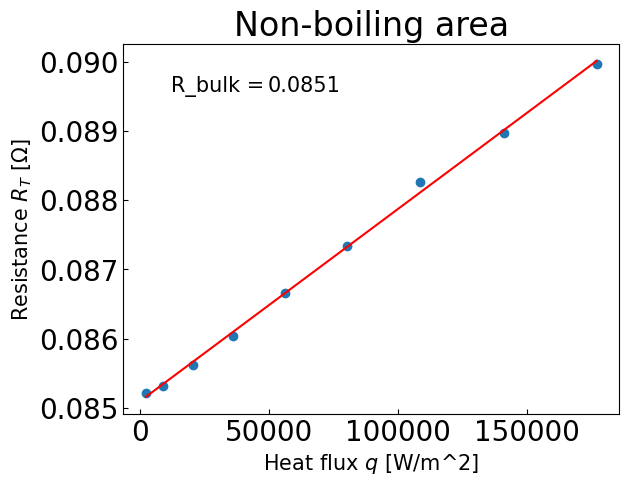

R_bulk :  0.08510766842194657


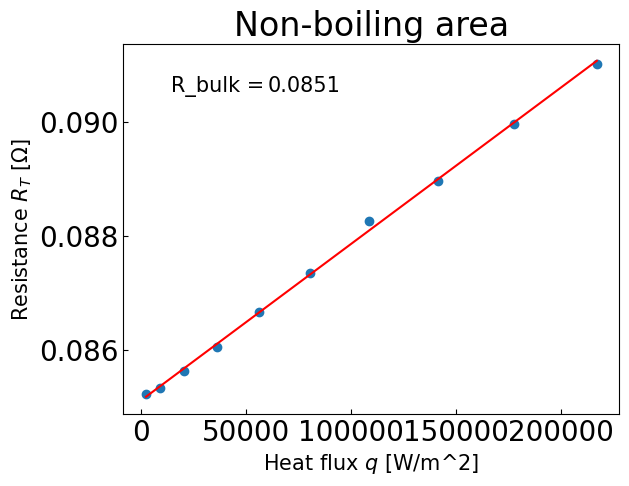

R_bulk :  0.08515888208106896


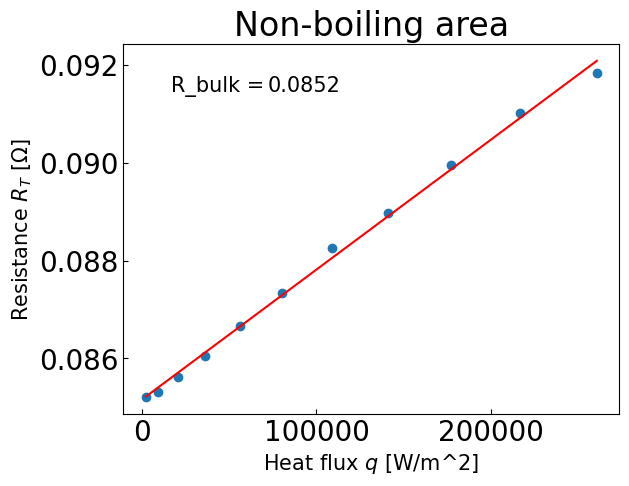

R_bulk :  0.08522528099106369


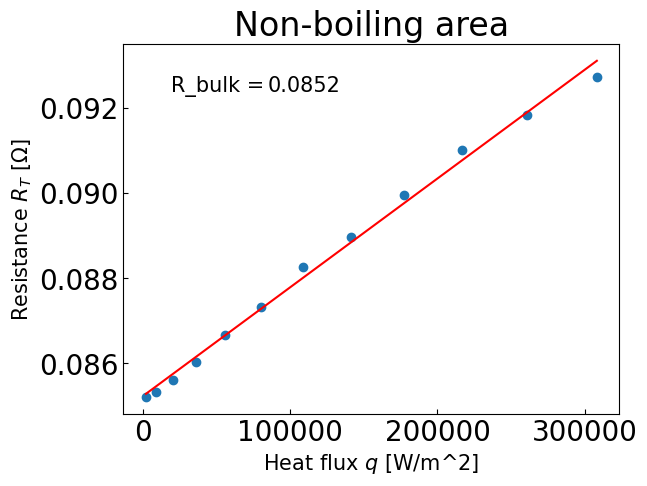

核沸騰開始点と判断した熱流束: 3.60e+05
直線が失われる1つ前の近似直線の切片: 0.08522528099106369


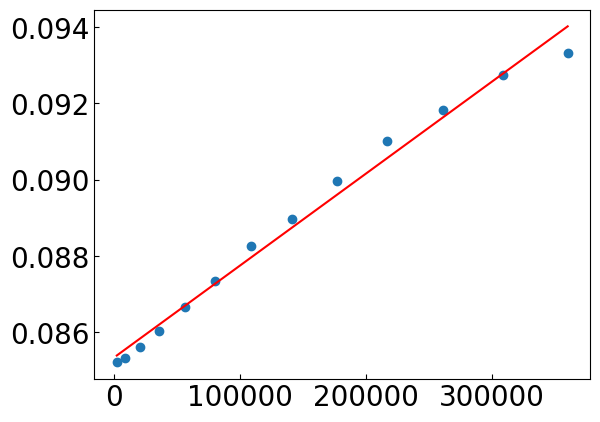

In [27]:
# -------------------------------------------------------------------------------------
#                       各パラメータ算出部
# -------------------------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.ticker as ptick 
from scipy.stats import linregress

#円周率
pi = np.pi

#飽和温度(K)の算出
T_sat = 0.268 * P + 72.8   #飽和温度(℃)
T_sat = T_sat + 273.15     #飽和温度(K)
#print(T_sat)

#サブクール度の算出
T_sub = T_sat - (T_bulk + 273.15)
#print(T_sub)

#関数の定義
def Heat_flux(shunt, Pt):
    
    R_shunt = 1.667 * pow(10,-3)
    I = shunt / R_shunt
    R_Pt = Pt / I
    a = I * Pt
    b = pi * d * L
    q = a / b
    
    return R_Pt, q

list_R = []   #空の行列を用意
list_q = []   #空の行列を用意

#リストから数値を順に取り出して計算
for i in range(len(shunt_average)):
    shunt = shunt_average[i]
    Pt = Pt_average[i]
    R_Pt, q = Heat_flux(shunt, Pt)
    list_R = np.append(list_R, R_Pt)
    list_q = np.append(list_q, q)

#リスト化
list_R = list_R.tolist()
list_q = list_q.tolist()
#print(list_R)
#print(list_q)

#DataFrame用にリスト結合
mylist = list(zip(list_R, list_q))

#グラフ作成に用いる物性値のDataFrameを作成
df_graph = pd.DataFrame(mylist, columns=['R_Pt', 'q'])

# -------------------------------------------------------------------------------------
##ファイルのrename用にDataframeをcsvファイルに変換
df_heat_flux = df_graph.drop(columns='R_Pt')  #不要な部分を削除
df_heat_flux['volt'] = df_heat_flux.index * 0.1    #印可電圧の列を作成
df_heat_flux['q(e)'] = df_heat_flux['q'] 
df_heat_flux = df_heat_flux.reindex(columns=['volt', 'q', 'q(e)'])  #Dataframeの列順の入れ替え

#ファイルに書き込むファイルのフォーマットの指定
df_heat_flux['volt']=df_heat_flux['volt'].apply(lambda x: f'{x:.1f}V')  
df_heat_flux['q(e)']=df_heat_flux['q(e)'].apply(lambda x: f'{x:.2e}')

df_heat_flux.to_csv(os.path.join(save_path, 'heat_flux_' + os.path.basename(dir_path) + '.csv'), index=False)
# -------------------------------------------------------------------------------------

#非沸騰領域のグラフ作成に用いる物性値のDataFrameを作成(0.1V～のデータを使用)
df_nonboil = df_graph.drop(df_graph.index[0])

#R_bulkの算出(非沸騰領域のデータの直線性を調査し、その直線性が維持される最大電圧時の切片)
##非沸騰領域のグラフ作成

# グラフの初期化
plt.figure()

# 直線が失われる前の近似直線の切片を保存する変数
prev_intercept = None

# インデックスを1つずつ増やしながらグラフを作成し、直線性を判定する
for i in range(len(df_nonboil) - 1):
    x = df_nonboil['q'][:i+2]  # インデックスを1つずつ増やす
    y = df_nonboil['R_Pt'][:i+2]   # 列 'y' のデータをスライスして取得
    
    if len(x) < dataplot_min:
        continue             #データ点が8未満である場合は判定をスキップ
    
    #最小二乗法で直線を求める
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    #軸の文字サイズの一括変更
    plt.rcParams["font.size"] = 20
    plt.rcParams['xtick.labelsize'] = 20 # 軸だけ変更
    plt.rcParams['ytick.labelsize'] = 20 # 軸だけ変更
    
    #プロット点と近似直線を描画
    #fig = plt.scatter(x, y, label=f'Iteration {i+1}')
    #plt.plot(x, slope*x + intercept, color='red')
    fig, ax0 = plt.subplots()
    ax0.scatter(x, y, label=f'Iteration {i+1}')
    ax0.plot(x, slope*x + intercept, color='red')
    
    #直線性の判定
    if r_value < 0.995 and prev_intercept is not None:  # 直線性が失われた場合(0.995)
        #print("直線性が失われました。ループを終了します。")
        
        lost_x = x.iloc[-1]
        #print("直線が失われた直後の熱流束:", lost_x)
        print("核沸騰開始点と判断した熱流束:", "{:.2e}".format(lost_x))
        break
    
    #直線が失われる前の近似直線の切片を保存
    prev_intercept = intercept
    R_bulk = prev_intercept
    print("R_bulk : ", R_bulk)
    
    #グラフ枠外に最大ピークの値を配置
    ax0_pos = ax0.get_position()
    fig.text(ax0_pos.x1 - 0.70, ax0_pos.y1 - 0.1, 'R_bulk =', fontsize=15)
    fig.text(ax0_pos.x1 - 0.55, ax0_pos.y1 - 0.1, '{:.4f}'.format(R_bulk), fontsize=15)

    #グラフのラベル
    plt.xlabel('Heat flux $q$ [W/m^2]',fontsize=15)
    plt.ylabel('Resistance $R_T$ [Ω]',fontsize=15)
    plt.title('Non-boiling area')

    #グラフを表示
    plt.savefig(os.path.join(save_area_path, '非沸騰領域.png'), bbox_inches='tight')
    plt.show()

#直線が失われる前の近似直線の切片(R_bulk)
#R_bulk = prev_intercept
print("直線が失われる1つ前の近似直線の切片:", R_bulk)

#白金温度Tの算出
def Temperature(T_bulk, R_bulk, list_R):
    
    #測温体定数
    A = 3.9083 * pow(10,-3)
    B = -5.7750 * pow(10,-7)
    
    #R_0の算出
    under = 1 + A * T_bulk + B * T_bulk * T_bulk
    R_0 = R_bulk / under
    
    #白金温度Tの算出
    root = math.sqrt(A * A - 4 * B *(1 - (list_R / R_0)))
    top = - A + root
    T = top / (2 * B)
    
    return T

Temp = []     #空の行列を用意
Superheat = []   #空の行列を用意
delta_h = []   #空の行列を用意

for i in range(len(df_graph.index)):
    list_R = df_graph['R_Pt'][i]   #白金抵抗
    list_q = df_graph['q'][i]      #熱流束
    T = Temperature(T_bulk, R_bulk, list_R)   #白金温度の算出
    Super = (T + 273.15) - T_sat              #過熱度の算出
    deltah = list_q / Super                   #Δhの算出
    Temp.append(T)
    Superheat.append(Super)
    delta_h.append(deltah)
Temp = Temp
Superheat = Superheat
delta_h = delta_h

# -------------------------------------------------------------------------------------
##念のため、白金温度をDataframeをcsvファイルに変換
Pt_Temp = list(Temp)
df_Pt_Temp= pd.DataFrame(Pt_Temp, columns=['T'])  
df_Pt_Temp['volt'] = df_Pt_Temp.index * 0.1    #印可電圧の列を作成 
df_Pt_Temp = df_Pt_Temp.reindex(columns=['volt', 'T'])  #Dataframeの列順の入れ替え

#ファイルに書き込むファイルのフォーマットの指定
df_Pt_Temp['volt']=df_Pt_Temp['volt'].apply(lambda x: f'{x:.1f}V')  
df_Pt_Temp['T']=df_Pt_Temp['T'].apply(lambda x: f'{x:.1f}')

df_Pt_Temp.to_csv(os.path.join(save_path, 'Volt_T_' + os.path.basename(dir_path) + '.csv'), index=False)
# -------------------------------------------------------------------------------------

#print(Temp)
#print(Superheat)
#print(delta_h)

#DataFrame用にリスト結合
newlist = list(zip(Superheat, delta_h))

#核沸騰伝熱の相関式グラフ作成に用いる物性値のDataFrameを作成
df_Temp = pd.DataFrame(newlist, columns=['ΔT_sat', 'Δh'])

#熱流束と白金抵抗のDataFrame(df_graph)とdf_Tempの横方向(axis=1)の連結
df_boiling_area = pd.concat([df_Temp, df_graph], axis=1)

#不必要なDataFrameの列を削除
df_nucleate_boiling_area = df_boiling_area.drop(columns='R_Pt')

#過熱度＞0の条件で抽出
df_nucleate_boiling_area = df_nucleate_boiling_area.query('q >= @lost_x')

#index番号の振り直し
df_nucleate_boiling_area = df_nucleate_boiling_area.reset_index(drop=True)


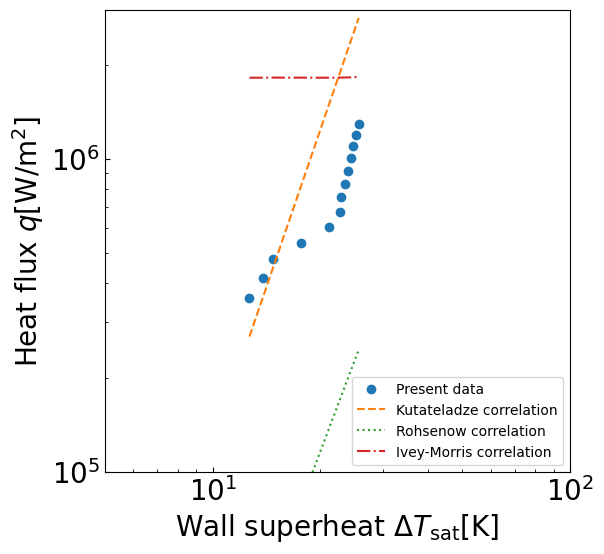

In [28]:
# -------------------------------------------------------------------------------------
#                       沸騰曲線作成部
# -------------------------------------------------------------------------------------

def sat_boiling(delta_h):
    
    #液温100℃のパラメータ
    L_lv = 2.26 * pow(10,6)     #蒸発潜熱[J/kg]
    p = P * pow(10,3)           #系の圧力[Pa]
    C_pl = 4.22 * pow(10,3)    #液体の定圧比熱[J/(kg・K)]
    rho_l = 958.4               #液体の密度[kg/m^3]
    rho_v = 0.5981              #蒸気の密度[kg/m^3]
    sigma = 5.89 * pow(10,-2)   #表面張力[N/m]
    g = 9.7975                  #重力加速度[m/s^2]
    
    #comma要素ごとに記述
    #Zuber
    Z_1 = delta_h * rho_v
    Z_2 = ((sigma * g * (rho_l - rho_v)) / (rho_v * rho_v)) ** (1/4)
    
    q_sat = 0.131 * Z_1 * Z_2
    
    return q_sat

def nucleate_boiling(Superheat, delta_h, q_sat, T_sub):
    
    #各液温でのパラメータ
    if  Setting_Temp == 70:
        #液温70℃のパラメータ
        L_lv = 2.333 * pow(10,6)     #蒸発潜熱[J/kg]
        p = P * pow(10,3)            #系の圧力[Pa]
        P_rl = 2.565                 #液体のプラントル数
        rho_l = 9.777 * pow(10,2)    #液体の密度[kg/m^3]
        rho_v = 0.1984               #蒸気の密度[kg/m^3]
        k_l = 0.6596                 #液体の熱伝導率[W/(m・K)]
        sigma = 6.448 * pow(10,-2)   #表面張力[N/m]
        g  = 9.7975                  #重力加速度[m/s^2]
        myu_l = 4.039 * pow(10,-4)    #液体の粘性率[Pa・s]
        C_sf = 0.013                 #係数(水-白金)
        C_pl = 4.188 * pow(10,3)      #液体の定圧比熱[J/(kg・K)]
        v_l = myu_l / rho_l          #液体の動粘度[m^2/s]
        l_a = math.sqrt(sigma / (g * (rho_l - rho_v)))  #ラプラス係数
    
    elif Setting_Temp == 80:
        #液温80℃のパラメータ
        L_lv = 2.308 * pow(10,6)     #蒸発潜熱[J/kg]
        p = P * pow(10,3)            #系の圧力[Pa]
        P_rl = 2.229                 #液体のプラントル数
        rho_l = 9.718 * pow(10,2)    #液体の密度[kg/m^3]
        rho_v = 0.2937               #蒸気の密度[kg/m^3]
        k_l = 0.667                  #液体の熱伝導率[W/(m・K)]
        sigma = 6.267 * pow(10,-2)   #表面張力[N/m]
        g  = 9.7975                  #重力加速度[m/s^2]
        myu_l = 3.543 * pow(10,-4)    #液体の粘性率[Pa・s]
        C_sf = 0.013                 #係数(水-白金)
        C_pl = 4.196 * pow(10,3)      #液体の定圧比熱[J/(kg・K)]
        v_l = myu_l / rho_l          #液体の動粘度[m^2/s]
        l_a = math.sqrt(sigma / (g * (rho_l - rho_v)))  #ラプラス係数
        
    elif Setting_Temp == 90:
        #液温90℃のパラメータ
        L_lv = 2.283 * pow(10,6)     #蒸発潜熱[J/kg]
        p = P * pow(10,3)            #系の圧力[Pa]
        P_rl = 1.964                 #液体のプラントル数
        rho_l = 9.653 * pow(10,2)    #液体の密度[kg/m^3]
        rho_v = 0.4239               #蒸気の密度[kg/m^3]
        k_l = 0.673                 #液体の熱伝導率[W/(m・K)]
        sigma = 6.082 * pow(10,-2)   #表面張力[N/m]
        g  = 9.7975                  #重力加速度[m/s^2]
        myu_l = 3.144 * pow(10,-4)   #液体の粘性率[Pa・s]
        C_sf = 0.013                 #係数(水-白金)
        C_pl = 4.205 * pow(10,3)      #液体の定圧比熱[J/(kg・K)]
        v_l = myu_l / rho_l          #液体の動粘度[m^2/s]
        l_a = math.sqrt(sigma / (g * (rho_l - rho_v)))  #ラプラス係数

    #comma要素ごとに記述
    #Kutateladze
    K_1 = 7.0 * pow(10, -4) * (P_rl ** 0.35)
    K_2 = (1 / (rho_v * L_lv * v_l)) ** 0.7
    K_3 = (p / sigma) ** 0.7
    K_4 = k_l * (l_a ** 0.4) * Superheat
    
    Kutate_q = (K_1 * K_2 * K_3 * K_4) ** (10/3)

    #Rohsenow
    R_1 = (P_rl ** (-0.7)) / C_sf
    R_2 = (1 / (rho_v *  v_l * L_lv)) ** 0.67
    R_3 = (rho_v / rho_l) ** 0.67
    R_4 = k_l * (l_a ** (-0.33)) * Superheat
    
    Rohse_q = (R_1 * R_2 * R_3 * R_4) ** (100/33)
    
    #Ivey-Moris
    I_1 = (rho_v / rho_l) ** (1/4)
    I_2 = (C_pl * rho_l * T_sub) / (delta_h * rho_v)
    
    q_sub = q_sat * (1 + (0.1 * I_1 * I_2))
    
    return Kutate_q, Rohse_q, q_sub

Kutateladze = []     #空の行列を用意
Rohsenow = []   #空の行列を用意
Zuber = []   #空の行列を用意
Ivey_Moris = []   #空の行列を用意

#核沸騰伝熱特性の相関式の算出
for i in range(len(df_nucleate_boiling_area.index)):
    delta_h = df_nucleate_boiling_area['Δh'][i]        #Δh
    Superheat = df_nucleate_boiling_area['ΔT_sat'][i]  #過熱度
    q_sat = sat_boiling(delta_h)
    Kutate_q, Rohse_q, q_sub = nucleate_boiling(Superheat, delta_h, q_sat, T_sub)
    Zuber.append(q_sat)
    Kutateladze.append(Kutate_q)
    Rohsenow.append(Rohse_q)
    Ivey_Moris.append(q_sub)
    
Kutateladze = Kutateladze
Rohsenow = Rohsenow
Zuber = Zuber
Ivey_Moris = Ivey_Moris
#print(Kutateladze)
#print(Rohsenow)
#print(Ivey_Moris)

#DataFrame用にリスト結合
boiling_list = list(zip(Kutateladze, Rohsenow, Ivey_Moris))

#核沸騰伝熱の相関式のDataFrameを作成
df_boiling = pd.DataFrame(boiling_list, columns=['Kutateladze correlation', 'Rohsenow correlation', 'Ivey-Morris correlation'])

#加熱度＆熱流束等とdf_boilingの横方向(axis=1)の連結
df_compare = pd.concat([df_nucleate_boiling_area, df_boiling], axis=1)

#不必要なDataFrameの列を削除
df_compare = df_compare.drop(columns='Δh')

#df_compare抽出(相関式の直線を担保するため）
df_compare_ext = df_compare.drop(columns='q')
df_compare_ext_plot = df_compare_ext.iloc[[0, -1]]

# グラフを描画する
plt.figure(figsize = (6,6))

# 測定データをグラフをプロットする
plt.plot(df_compare['ΔT_sat'], df_compare['q'], marker='o', linestyle='', label='Present data')

#グラフを対数に変更
plt.xscale('log')
plt.yscale('log')

#核沸騰伝熱特性の相関式をグラフをプロットする
linestyles = ['--', ':', '-.']

for i, column in enumerate(['Kutateladze correlation', 'Rohsenow correlation', 'Ivey-Morris correlation']):
    plt.plot(df_compare_ext['ΔT_sat'], df_compare_ext[column], linestyle=linestyles[i], label=column)
    # plt.plot(df_compare_ext_plot['ΔT_sat'], df_compare_ext_plot[column], linestyle=linestyles[i], label=column)

    ###---------------------------------------------------------------------------------------------------------------------------
    #Dataframeのデータから各相関式の直線の式を求めてからグラフにプロットする手法
    #numpyのpolyfit関数で直線の係数を計算
    #cor_x = df_compare_ext_plot['ΔT_sat']
    #cor_y = df_compare_ext_plot[column]
    #slope_cor, intercept_cor = np.polyfit(cor_x, cor_y, 1)  # 直線の係数を計算(直線なら(x座標,y座標 ,1)となる)
    #plt.plot(cor_x, slope_cor * cor_x + intercept_cor, linestyle=linestyles[i], label=column)  # フィッティングした直線をプロット
    ###---------------------------------------------------------------------------------------------------------------------------

#凡例の設定
plt.legend(loc=(0.53, 0.015), fontsize = 10)

#目盛を内向きに設定
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

#軸の設定
plt.xlim(5,100)
plt.ylim(100000,3000000)
plt.xlabel('Wall superheat $\Delta T_{\mathrm{sat}} [\mathrm{K}]$',fontsize=20)
plt.ylabel('Heat flux $q [\mathrm{W}/\mathrm{m}^2]$' ,fontsize=20)

plt.savefig(os.path.join(save_area_path, '核沸騰伝熱特性の相関式との比較.png'), bbox_inches='tight')
plt.savefig(os.path.join(save_area_all_path, os.path.basename(dir_path) +'.png'), bbox_inches='tight') #直径ごとの比較用
plt.show()


In [29]:
# -------------------------------------------------------------------------------------
#                       分析パラメータ出力部
# -------------------------------------------------------------------------------------
output_text1 = "Ultrapure water T_bulk: {:.2f}".format(T_bulk)
output_text2 = "intercept of nucleate_boiling prestart(R_bulk): {:.2e}".format(R_bulk)
output_text3 = "heat flux of nucleate_boiling start: {:.2e}".format(lost_x)

# ファイルを開いて内容を書き込む
with open(os.path.join(save_path, os.path.basename(dir_path)) + '.txt', "w") as file:
    file.write(f"{output_text1}\n") # 実験中の水温の時間平均
    file.write(f"{output_text2}\n") # 直線が失われる1つ前の近似直線の切片(非沸騰領域の議論)
    file.write(f"{output_text3}\n") # 核沸騰開始点と判断した熱流束

In [30]:
# -------------------------------------------------------------------------------------
#                       共振周波数算出部
# -------------------------------------------------------------------------------------

##パラメータ(不変)
#白金細線の長さ(弛みによる誤差を想定±2％)
#L1 = 4.01 * pow(10,-2)
#L2 = 4.10 * pow(10,-2)
L1 = L * 1.0025
L2 = L * 1.025

#円周率
pi = np.pi

#ヤング率の係数
alpha = 1.873
beta = 2.891* pow(10,-4)
gamma = -1.107 * pow(10,-6)
delta = 9.824 * pow(10,-10)
epsilon = -3.2 * pow(10, -13)

#膨張率の定数
C1 = 7.543 * pow(10,-6)
C2 = 2.362 * pow(10,-9)

#共振周波数の最後の2乗部分の格納
ni_jyo = [3.011, 5, 7, 9, 11, 13]

ni_jyo = [a * a for a in ni_jyo]

ni_jyo = ni_jyo

def resonance_F(d, T):

    #白金温度[K]
    T = T + 273.15

    #ヤング率E
    E = (alpha + (beta * T) + (gamma * T*T) + (delta * T*T*T) + (epsilon * T*T*T*T)) * pow(10,11)

    #長さL_T
    L1_T = L1 + (L1 * C1 *(T - 291)) + (L1 * C2 *(T - 291)*(T - 291))
    L2_T = L2 + (L2 * C1 *(T - 291)) + (L2 * C2 *(T - 291)*(T - 291))

    #直径d_T
    d_T =  d + (d * C1 *(T - 291)) + (d * C2 *(T - 291)*(T - 291))

    #白金密度
    rho1_T = 2.145 * pow(10,4) * ((d / d_T) * (d / d_T)) * (L1 / L1_T)
    rho2_T = 2.145 * pow(10,4) * ((d / d_T) * (d / d_T)) * (L2 / L2_T)

    #回転半径K
    K = d_T / 4

    list_x = []
    list_y = []
    
    for i in range(len(ni_jyo)):
        #共振周波数算出
        x = (((pi * K) / (8 * L1_T * L1_T)) * math.sqrt(E / rho1_T)) * ni_jyo[i]
        y = (((pi * K) / (8 * L2_T * L2_T)) * math.sqrt(E / rho2_T)) * ni_jyo[i]
        
        #計算値の小数点を設定(小数点第二位)
        x = '{:.2f}'.format(x)
        y = '{:.2f}'.format(y)
        list_x.append(x)
        list_y.append(y)

    return list_x, list_y


list_reso = []

for i in range(len(Temp)):
    
    T = Temp[i]                 #リスト(Temp)の中身を順次、変数Tに格納
    x, y = resonance_F(d, T)    #白金温度Tにおける共振周波数の算出
    reso = x + y                #弛みによる誤差を考慮して算出した2種類の共振周波数を結合
    T_0 = Temp[0]   #白金温度が0℃の時のみ特別に抽出
    
    #リストの中身の型をstr型からfloat型に変更
    reso = list(map(float, reso))      #後方の共振周波数→前方の共振周波数の順
    list_reso.append(reso)

#白金温度:0℃の時(稀に白金温度が負の値になる)
if T_0 < 0:
    list_reso = [list_reso[0]] + list_reso  #全ての白金温度における共振周波数の値を格納,ただし0.0Vの場合暫定で0.1Vのものを使用
else:
    list_reso = list_reso
#print((list_reso))
#print(len(list_reso))

# -------------------------------------------------------------------------------------
##念のため、白金温度をDataframeをcsvファイルに変換
df_Reso= pd.DataFrame(a for a in list_reso)  
df_Reso['volt'] = df_Pt_Temp['volt']    #印可電圧の列を作成 
#df_Reso = df_Reso.reindex(columns=['volt', 'Reso'])  #Dataframeの列順の入れ替え

#ファイルに書き込むファイルのフォーマットの指定
#df_Reso['volt']=df_Reso['volt'].apply(lambda x: f'{x:.1f}V')  
#df_Reso['Reso']=df_Reso['Reso'].apply(lambda x: f'{x:.2e}')

df_Reso.to_csv(os.path.join(save_path, 'T_Reso_' + os.path.basename(dir_path) + '.csv'), index=False)
# -------------------------------------------------------------------------------------


In [31]:
# -------------------------------------------------------------------------------------
#                       周波数解析部
# -------------------------------------------------------------------------------------

import soundfile as sf
import scipy as sp
from scipy import signal
import random
import os

##データ条件
#高速フーリエ変換の周波数帯の設定
minHz = 0
#maxHz = maxHz

#フィルター条件
#フィルターONならTrue,OFFならFalse
filter_on_or_off = True

#除去方法(High_pass? Low_pass?)
high_and_low = "high"

#周波数条件の設定
f_pass = 500  #通過周波数
f_stop = 100  #除去周波数

#減衰率(dB)の設定
g_pass = 3
g_stop = 40

#周波数の時間
time = 60
df = 1/time   #周波数空間におけるデータ間の間隔[Hz]
k = 1.0/ df

#ホワイトノイズ強度
noise_intensity = 0.1
noise_on = False
if(noise_on == False):
    noise_intensity = 0
mean = 0

##関数の定義

#フーリエ変換処理
def power_spectrum(time_data, samplerate):
    quantity = len(time_data)
    window_func = np.hanning(quantity)
    windowed_data = time_data * window_func
    
    #フーリエ変換
    spectrum = np.fft.fft(windowed_data)
    
    #窓関数補正
    spectrum = 1/(sum(window_func)/quantity) * spectrum
    
    #amplitude
    amplitude = np.abs(spectrum/(quantity/2))
    
    power = amplitude ** 2
    
    return power

#正規化
def min_max(time_data, axis=None):
    min = time_data.min(axis=axis, keepdims=True)
    max = time_data.max(axis=axis, keepdims=True)
    
    normalized_data = (time_data-min)/(max-min)
    
    return normalized_data

def alias_filter(x, samplerate, fp, fs, gpass, gstop , high_or_low):
    fn = samplerate / 2
    
    #ナイキスト周波数で通過周波数と阻止周波数を正規化
    wp = fp / fn
    ws = fs / fn
    
    N,Wn = sp.signal.buttord(wp, ws, gpass, gstop)
    b, a = sp.signal.butter(N,Wn, high_or_low)
    y = sp.signal.filtfilt(b, a, x)
    return y 

#周波数解析した結果の表示
def analysis(input_folder, save_power_path, list_reso, maxHz):
    
    #出力フォルダ(ディレクトリ)の作成
    os.makedirs(save_power_path, exist_ok=True)

    #二次元配列：list_resoをファイルごとに適用
    #フォルダ内の全て音声ファイルに処理を実行
    for KYO, filename in enumerate(os.listdir(input_folder)):
        if filename.endswith('wav'):
            wav_file_path = os.path.join(input_folder, filename)
            name=os.path.splitext(os.path.basename(wav_file_path))[0]
            data, samplerate = sf.read(wav_file_path)

            reso_middle = list_reso[KYO]

            #音のサンプリングデータのうち、周波数空間に移したい時間分のデータ総量を指定
            data_quantity = int(samplerate * time)

            #ノイズデータ（使うマイク次第ではデータの形状が違うのでそれに依らずデータをとれるように）
            if(data.ndim == 2):
                w = np.array([np.random.normal(mean,noise_intensity) for i in range(len(data[:,0]))])
            else:
                w = np.array([np.random.normal(mean,noise_intensity) for i in range(len(data[:]))])

            if(noise_on == True):
                if(data.ndim == 2):
                    data[:,0] += w
                else:
                    data += w

            if(filter_on_or_off == True):#フィルターに代入時に、使うデータの範囲指定も行う。
                #ローパスフィルターにかけてaliasを除去
                if(data.ndim == 2):
                    raw_data = alias_filter(data[0:data_quantity,0], samplerate , f_pass , f_stop , g_pass , g_stop , high_and_low)
                else:
                    raw_data = alias_filter(data[0:data_quantity], samplerate , f_pass , f_stop , g_pass , g_stop , high_and_low)
            else:
                if(data.ndim == 2):
                    raw_data = data[0:data_quantity,0]
                else:
                    raw_data = data[0:data_quantity]

            #時間軸の設定
            t=np.arange(0,time,1/samplerate)

            if maxHz == 3000:

                #RMS計算
                rms = np.sqrt(np.square(raw_data).mean(axis=0))
                #print('rms =',rms)
            
                #グラフ枠外にRMS計算結果を配置
                fig = plt.figure()
                ax0 = fig.add_subplot(111)
                ax0_pos = ax0.get_position()
                fig.text(ax0_pos.x1 - 0.33, ax0_pos.y1 + 0.01, 'rms =')
                fig.text(ax0_pos.x1 - 0.13, ax0_pos.y1 + 0.01, '{:.8f}'.format(rms))
    
                #出力
                #plt.title(name)
                plt.plot(t,raw_data)
                plt.xlim(0, time)
                plt.xlabel('Time [s]')
                plt.ylabel('Amplitude a.u.')
    
                #ファイルに保存
                plt.savefig(os.path.join(save_time_path,name+'_time.png'))
                plt.show()

            ##高速フーリエ変換
            ##FFTセル(Power Spectrum)

            start = 0
            samplequan = k * samplerate
            overlap_rate = 50 #%表示
            ovr = overlap_rate/100

            orig = np.zeros(int((maxHz - minHz)*k))

            for i in range(int(len(raw_data)/(samplequan*(1-ovr)))):
                start = start + int(samplequan*(1-ovr))
    
                if(i == 0):
                    start = 0
    
                finish = start + int(samplequan)
    
                #pow
                if(finish <= len(raw_data)):
                    power=power_spectrum(raw_data[start:finish],samplerate)
        
                    #指定した周波数帯の情報
                    power=power[int(minHz*k):int(maxHz*k)]
                    normypow=min_max(power)
       
                    #図示
                    freqlist = np.fft.fftfreq(int(samplequan), d= 1.0/samplerate)
                    maxindex2 = np.argmax(power[int(minHz*k):int(maxHz*k)])
                    freq = freqlist[int(minHz*k):int(maxHz*k)]
                    print("maxvalue frequency:",freq[maxindex2])
                    
                    #軸の文字サイズの一括変更
                    plt.rcParams["font.size"] = 30
                    plt.rcParams['xtick.labelsize'] = 31 # 軸だけ変更
                    plt.rcParams['ytick.labelsize'] = 31 # 軸だけ変更
        
                    #目盛を内向きに設定
                    plt.rcParams['xtick.direction'] = 'in'
                    plt.rcParams['ytick.direction'] = 'in'
    
                    fig = plt.figure(figsize = (10,10))
                    ax1 =fig.add_subplot(111)
                    ax1.yaxis.offsetText.set_fontsize(30)
                
                    #グラフ枠外に最大ピークの値を配置
                    #ax1_pos = ax1.get_position()
                    #fig.text(ax1_pos.x1 - 0.22, ax1_pos.y1 + 0.01, 'max peak Freq [Hz] =')
                    #fig.text(ax1_pos.x1 - 0.06, ax1_pos.y1 + 0.01, '{:.2f}'.format(freq[maxindex2]))
                    
                    #共振周波数の設定
                    for i in range(len(reso_middle)):
                        if i < 6:
                            ax1.axvline(reso_middle[i], ymin=0.0, ymax=0.95, color='green',lw=2, ls='--', alpha=0.6)
                        elif i >= 6:
                            ax1.axvline(reso_middle[i], ymin=0.0, ymax=0.95, color='red',lw=2, ls='--', alpha=0.6)
                            
                    size = 20
                    #図のy軸の上限決定
                    if(i == 0):
                        limitAy = np.max(normypow)
        
                    #出力(freq-pow)
                    #plt.title(name)
                    plt.plot(freq, normypow)
                    plt.xlim(minHz,maxHz)
                    plt.xlabel('Frequency [Hz]')
                    plt.ylabel('Power Spectrum a.u.')
                    plt.grid()

                    #ファイルに保存
                    plt.savefig(os.path.join(save_power_path,name+'_Pow.png'))
                    plt.show()
            pass
    
    return freq, normypow
    
#録音データを周波数解析し、Power Spectrumを作成
#analysis(input_folder, save_power_path, list_reso)


In [32]:
# -------------------------------------------------------------------------------------
#                       周波数解析結果出力部
# -------------------------------------------------------------------------------------

#録音データを周波数解析し、Power Spectrumを作成
# for maxHz in list_maxHz:
#     #保存フォルダの作成
#     save_power_path = os.path.join(save_path, 'pow_' + str(maxHz) +'Hz')
#     os.makedirs(save_power_path, exist_ok=True)
#     #パワースペクトル作成
#     analysis(input_folder, save_power_path, list_reso, maxHz)



In [33]:
# df_compare_ext_plot
df_compare_ext

,ΔT_sat,Kutateladze correlation,Rohsenow correlation,Ivey-Morris correlation
0,12.67469777,270436.36349879,29071.46500395,1817667.10071154
1,13.80489074,359514.40140252,37659.72147986,1818537.43594913
2,14.78502937,451870.18250146,46360.43055244,1819578.30362183
3,17.64067593,814061.31694761,79168.16561092,1818750.88499006
4,21.13495665,1486885.69601306,136894.93150102,1817784.21556686
5,22.67953699,1880992.19232969,169517.33047294,1818374.10130683
6,22.80847871,1916876.40041861,172454.73405826,1819945.43251384
7,23.53005533,2126585.62383753,189524.30174115,1821113.67803205
8,23.95053738,2255921.17009365,199974.65085844,1822546.45473549
9,24.43416617,2411375.19750060,212463.74331544,1823947.42577087
